# 01 — Khảo sát dữ liệu

Bước đầu tiên của quy trình: hiểu dữ liệu trước khi đụng tới mô hình.

Notebook này trả lời bốn câu hỏi:

1. Dữ liệu có **đủ dài** và **đủ sạch** không?
2. Chuỗi thời gian có **liên tục** không, hay bị đứt quãng?
3. Có **giá trị bất thường** nào cần xem lại không?
4. Bài toán phân loại có bị **mất cân bằng lớp** không?

> Theo quy ước của dự án, đây là tầng DUY NHẤT được phép khai báo giá trị cụ thể
> của đề tài (đường dẫn, tên cột, độ dài cửa sổ). Các module trong `src/libraries/`,
> `src/pipeline/` và `src/utilities/` chỉ nhận tham số, không tự biết gì về đề tài.

In [1]:
import os
import sys

# Đưa src/ vào đường dẫn tìm kiếm module để import được các package của dự án.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

import matplotlib.pyplot as plt
%matplotlib inline

from libraries import rfPlot
from pipeline import labeling, timePreprocess
from utilities import dataLoader, plotStyle

## 1. Cấu hình của lượt khảo sát

Toàn bộ giá trị cụ thể được gom về một chỗ để dễ đổi sang mã khác.

In [2]:
DATA_PATH   = os.path.join(PROJECT_ROOT, 'data', 'input', 'VNM.csv')
SYMBOL      = 'VNM'

DATE_COLUMN   = 'Date'
OPEN_COLUMN   = 'Open'
HIGH_COLUMN   = 'High'
LOW_COLUMN    = 'Low'
CLOSE_COLUMN  = 'Close'
VOLUME_COLUMN = 'Volume'
NUMERIC_COLUMNS = [OPEN_COLUMN, HIGH_COLUMN, LOW_COLUMN, CLOSE_COLUMN, VOLUME_COLUMN]

MAX_FORWARD_FILL         = 2
EXTREME_CHANGE_THRESHOLD = 0.40
LABEL_HORIZON            = 5

print(f'Mã       : {SYMBOL}')
print(f'Dữ liệu  : {DATA_PATH}')

Mã       : VNM
Dữ liệu  : E:\Data\Devdata\Freelancers\Miniproj\BOT--Machine-Learning\data\input\VNM.csv


## 2. Nạp dữ liệu và ép kiểu

In [3]:
headers, table = dataLoader.load_csv_data(DATA_PATH)

for name in NUMERIC_COLUMNS:
    table[name] = [None if value in (None, '') else float(value)
                   for value in table[name]]
table[DATE_COLUMN] = timePreprocess.parse_date_series(table[DATE_COLUMN])

print(f'\nSố dòng: {len(table[DATE_COLUMN])}')
print(f'Khoảng thời gian: {min(table[DATE_COLUMN])} → {max(table[DATE_COLUMN])}')

Đã đọc file: VNM.csv | Số dòng dữ liệu: 2587
Các cột: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Số dòng: 2587
Khoảng thời gian: 2016-08-22 → 2026-08-21


## 3. Làm sạch chuỗi thời gian

Thứ tự các bước bám đúng chuỗi ①→⑥ khai báo ở đầu `pipeline/timePreprocess.py`.

In [4]:
print('Ô thiếu trước khi làm sạch:', timePreprocess.count_missing_values(table))

table = timePreprocess.sort_table_by_column(table, DATE_COLUMN)
table = timePreprocess.remove_duplicate_keys(table, DATE_COLUMN)

for name in NUMERIC_COLUMNS:
    table[name] = timePreprocess.forward_fill_series(table[name], MAX_FORWARD_FILL)

table, kept_indices = timePreprocess.drop_rows_with_missing(table)
print(f'Sau khi làm sạch: {len(table[DATE_COLUMN])} dòng')

Ô thiếu trước khi làm sạch: {'Date': 0, 'Open': 0, 'High': 0, 'Low': 0, 'Close': 0, 'Volume': 0}
Sau khi làm sạch: 2587 dòng


### 3.1. Tính liên tục của chuỗi

Với dữ liệu chỉ ghi nhận ngày làm việc, khoảng cách 1 và 3 ngày là bình thường.
Khoảng cách lớn bất thường nghĩa là chuỗi thiếu đoạn, và mọi chỉ báo cửa sổ trượt
đi qua đoạn đó sẽ trộn lẫn hai giai đoạn cách xa nhau.

In [5]:
gaps = timePreprocess.summarize_key_gaps(table[DATE_COLUMN])

print('Phân bố khoảng cách giữa hai phiên liên tiếp (ngày → số lần):')
for gap, count in list(gaps['gap_counts'].items())[:8]:
    print(f'  {gap:>3} ngày : {count:>5} lần')
print(f"\nKhoảng cách lớn nhất: {gaps['largest_gap_days']} ngày "
      f"(tại vị trí {gaps['largest_gap_position']})")

Phân bố khoảng cách giữa hai phiên liên tiếp (ngày → số lần):
    1 ngày :  2059 lần
    2 ngày :     5 lần
    3 ngày :   514 lần
    4 ngày :     4 lần
    5 ngày :     2 lần
    6 ngày :     1 lần
    8 ngày :     1 lần

Khoảng cách lớn nhất: 8 ngày (tại vị trí 112)


### 3.2. Giá trị bất thường

Biến động vượt ngưỡng thường là dấu vết của lỗi dữ liệu hoặc của sự kiện làm gãy
chuỗi, không phải tín hiệu thật.

In [6]:
extremes = timePreprocess.detect_extreme_changes(
    table[CLOSE_COLUMN], EXTREME_CHANGE_THRESHOLD)

print(f'Số phiên biến động vượt {EXTREME_CHANGE_THRESHOLD:.0%}: {len(extremes)}')
for position, change in extremes[:10]:
    print(f'  {table[DATE_COLUMN][position]}  {change:+.2%}')

Số phiên biến động vượt 40%: 0


## 4. Thống kê mô tả từng cột

In [7]:
print(f"{'Cột':<10}{'n':>7}{'thiếu':>8}{'min':>14}{'max':>14}"
      f"{'trung bình':>14}{'độ lệch chuẩn':>16}")
print('-' * 83)
for name in NUMERIC_COLUMNS:
    stats = timePreprocess.describe_series(table[name])
    print(f"{name:<10}{stats['count']:>7}{stats['missing']:>8}"
          f"{stats['minimum']:>14,.2f}{stats['maximum']:>14,.2f}"
          f"{stats['mean']:>14,.2f}{stats['standard_deviation']:>16,.2f}")

Cột             n   thiếu           min           max    trung bình   độ lệch chuẩn
-----------------------------------------------------------------------------------
Open         2587       0     51,400.00    148,958.33     87,627.61       21,373.76
High         2587       0     55,200.00    149,305.56     88,375.83       21,538.34
Low          2587       0     51,400.00    147,986.11     86,909.16       21,199.84
Close        2587       0     52,000.00    149,166.67     87,595.10       21,414.71
Volume       2587       0          0.00306,020,000.00  2,530,825.06    8,729,028.29


## 5. Diễn biến giá và khối lượng

Đã lưu đồ thị: E:\Data\Devdata\Freelancers\Miniproj\BOT--Machine-Learning\data\output\VNM_01_price_history.png


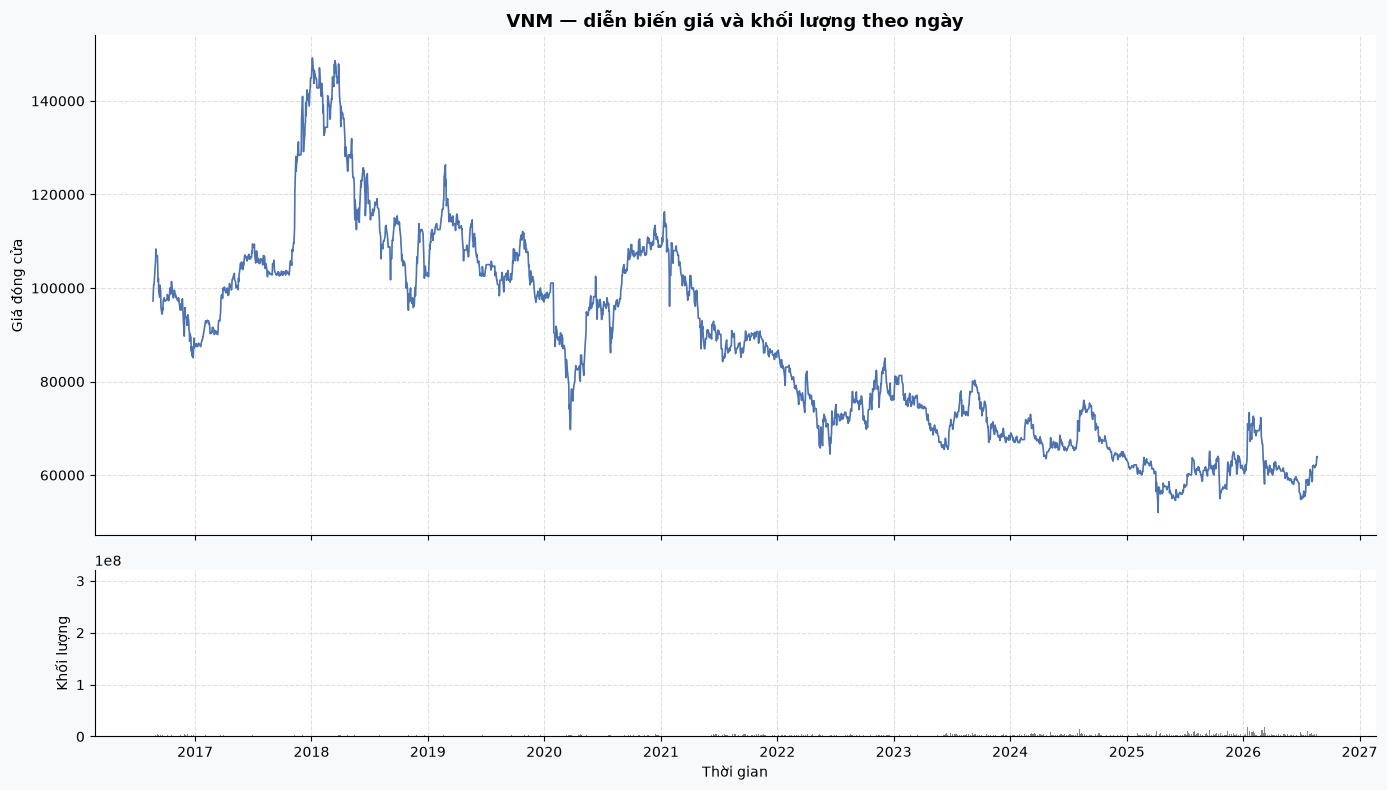

In [8]:
dates = table[DATE_COLUMN]
close = table[CLOSE_COLUMN]
volume = table[VOLUME_COLUMN]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor(plotStyle.FIGURE_BG_COLOR)

axes[0].plot(dates, close, color=plotStyle.POINT_COLOR, linewidth=1.2)
axes[0].set_ylabel('Giá đóng cửa')
axes[0].set_title(f'{SYMBOL} — diễn biến giá và khối lượng theo ngày',
                  fontsize=13, fontweight='bold')
plotStyle.apply_axes_style(axes[0])

axes[1].bar(dates, volume, color=plotStyle.NEUTRAL_COLOR, width=1.0)
axes[1].set_ylabel('Khối lượng')
axes[1].set_xlabel('Thời gian')
plotStyle.apply_axes_style(axes[1])

fig.tight_layout()
plotStyle.save_figure(fig, f'{SYMBOL}_01_price_history.png')
plt.show()

## 6. Phân bố tỷ suất biến động

Tỷ suất biến động là thang đo mà mô hình thực sự làm việc — quan trọng hơn mức
giá tuyệt đối, vì cây quyết định **không ngoại suy được** ra ngoài khoảng giá trị
đã thấy khi huấn luyện.

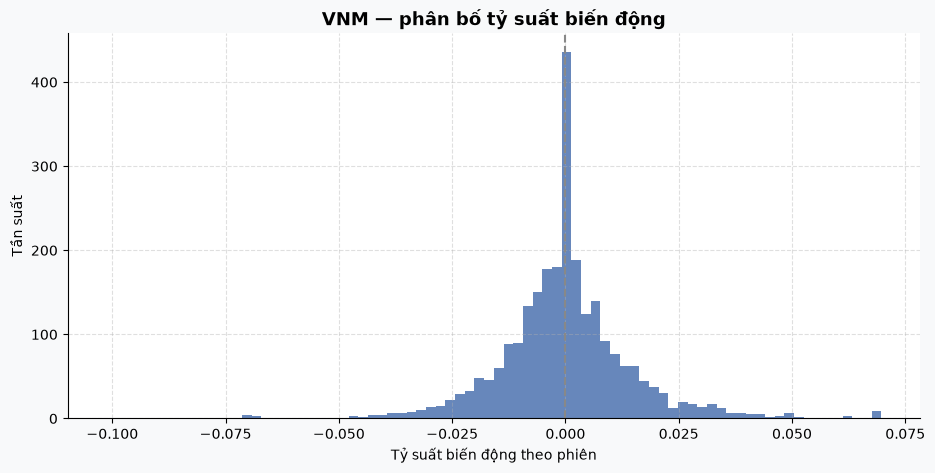

Trung bình      : -0.00005
Độ lệch chuẩn   : 0.01498
Nhỏ nhất        : -0.1013
Lớn nhất        : +0.0697


In [9]:
returns = [value for value in timePreprocess.calculate_simple_returns(close)
           if value is not None]
stats = timePreprocess.describe_series(returns)

fig, ax = plt.subplots(figsize=plotStyle.FIG_SIZE_COMPACT)
fig.patch.set_facecolor(plotStyle.FIGURE_BG_COLOR)
ax.hist(returns, bins=80, color=plotStyle.POINT_COLOR, alpha=0.85)
ax.axvline(0, color=plotStyle.NEUTRAL_COLOR, linestyle='--', linewidth=1.5)
ax.set_xlabel('Tỷ suất biến động theo phiên')
ax.set_ylabel('Tần suất')
ax.set_title(f'{SYMBOL} — phân bố tỷ suất biến động', fontsize=13, fontweight='bold')
plotStyle.apply_axes_style(ax)
plt.show()

print(f"Trung bình      : {stats['mean']:+.5f}")
print(f"Độ lệch chuẩn   : {stats['standard_deviation']:.5f}")
print(f"Nhỏ nhất        : {stats['minimum']:+.4f}")
print(f"Lớn nhất        : {stats['maximum']:+.4f}")

## 7. Cân bằng lớp — con số phải xem trước khi tin vào bất kỳ Accuracy nào

Một mô hình luôn đoán lớp chiếm đa số đã đạt Accuracy đúng bằng `majority_ratio`.
Mọi kết quả không vượt qua con số này đều vô nghĩa.

Ngoài ra cần đếm **số phiên đứng yên**: dồn hết chúng vào một phía sẽ tạo ra mất
cân bằng lớp GIẢ và khiến mô hình học cách luôn đoán lớp đó.

In [10]:
for horizon in (1, 5, 10):
    flat = labeling.count_flat_observations(close, horizon)
    labels = labeling.create_direction_labels(close, horizon=horizon)
    balance = labeling.calculate_class_balance(
        [label for label in labels if label is not None])
    print(f'horizon = {horizon:>2} | đứng yên = {flat["flat"]:>4} '
          f'({flat["flat_ratio"]:.1%}) | sau khi loại: {balance["counts"]} '
          f'| lớp đa số = {balance["majority_ratio"]:.1%}')

horizon =  1 | đứng yên =  355 (13.7%) | sau khi loại: {0: 1173, 1: 1058} | lớp đa số = 52.6%
horizon =  5 | đứng yên =   81 (3.1%) | sau khi loại: {0: 1338, 1: 1163} | lớp đa số = 53.5%
horizon = 10 | đứng yên =   37 (1.4%) | sau khi loại: {0: 1347, 1: 1193} | lớp đa số = 53.0%


Đã lưu đồ thị: E:\Data\Devdata\Freelancers\Miniproj\BOT--Machine-Learning\data\output\VNM_01_class_distribution.png


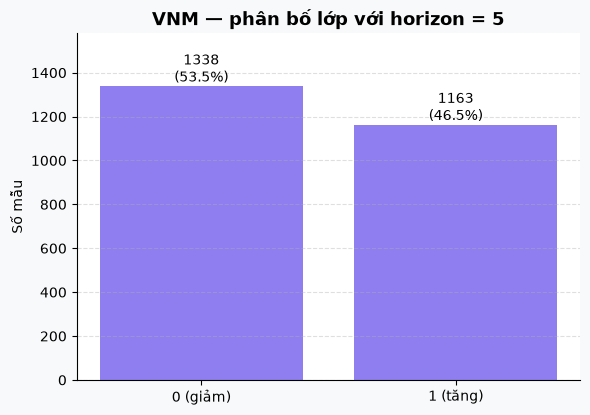

In [11]:
labels = labeling.create_direction_labels(close, horizon=LABEL_HORIZON)
balance = labeling.calculate_class_balance(
    [label for label in labels if label is not None])

rfPlot.plot_class_distribution(
    [f'{label} ({"tăng" if label == 1 else "giảm"})' for label in balance['counts']],
    list(balance['counts'].values()),
    title=f'{SYMBOL} — phân bố lớp với horizon = {LABEL_HORIZON}',
    filename=f'{SYMBOL}_01_class_distribution.png',
)
plt.show()

## 8. Kết luận của bước khảo sát

| Câu hỏi | Trả lời |
| --- | --- |
| Dữ liệu đủ dài? | ✔ hơn 2.500 phiên, vượt mức khuyến nghị 1.000 |
| Chuỗi liên tục? | ✔ khoảng cách lớn nhất nằm trong mức nghỉ lễ thông thường |
| Có giá trị bất thường? | ✔ không có phiên nào biến động vượt 40% |
| Lớp có cân bằng? | ✔ sau khi loại phiên đứng yên, tỷ lệ về mức chấp nhận được |

Bước tiếp theo: [`02_features.ipynb`](02_features.ipynb) — xây dựng bộ chỉ báo kỹ thuật.